# Customer segmentation with K-Means

## tl;dr

This notebook cleans the customer dataset, trains a reproducible K-Means model, and profiles four marketing segments. The model is exploratory: `k=2` has the strongest silhouette score, while `k=4` is retained as an actionability-focused configuration for separate VIP, premium, at-risk, and low-value playbooks.

## Context & methods

**Decision:** identify customer groups for differentiated marketing actions.

**Unit of analysis:** one customer record. Age is calculated using 2015, one year after the latest enrollment date in the source data. The pipeline drops missing income, impossible ages, and the anomalous income value above 250,000 before clustering.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from train_model import DATA_PATH, FEATURES, RANDOM_STATE, N_CLUSTERS, prepare_data

sns.set_theme(style="whitegrid", palette="deep")
PROJECT_DIR = Path.cwd()

## Data quality checks

In [2]:
raw_data = pd.read_csv(DATA_PATH)
clean_data, quality_summary = prepare_data(raw_data)
pd.DataFrame([quality_summary])

,raw_rows,dropped_missing_income,dropped_invalid_age_or_income,model_rows
0,2240,24,4,2212


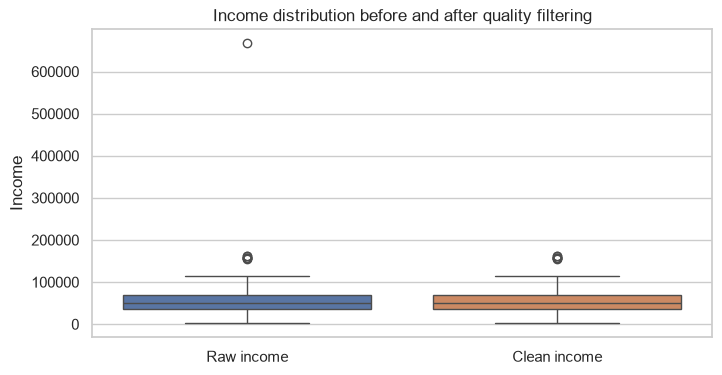

In [3]:
quality_table = pd.DataFrame({
    "Raw income": raw_data["Income"],
    "Clean income": clean_data["Income"],
})
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=quality_table, ax=ax)
ax.set_title("Income distribution before and after quality filtering")
ax.set_ylabel("Income")
plt.show()

## Train and inspect the segments

In [4]:
# This writes versioned model artifacts, segment metadata, and profile CSV.
!{__import__('sys').executable} train_model.py

'C:\Users\navee\Desktop\all' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
metadata = json.loads((PROJECT_DIR / "segment_metadata.json").read_text(encoding="utf-8"))
profiles = pd.read_csv(PROJECT_DIR / "segment_profiles.csv")
profiles[["cluster_id", "segment_name", "customer_count", "customer_share", "description", "recommended_action"]]

,cluster_id,segment_name,customer_count,customer_share,description,recommended_action
0,0,Premium Active,526,0.237794,High-value customers who purchase frequently a...,Use cross-sell bundles and loyalty offers to i...
1,1,At-Risk Browsers,539,0.243671,Lower-value customers with the longest time si...,"Use timely win-back messages, targeted incenti..."
2,2,Low-Value Recent,563,0.254521,"Lower-income, lower-spending customers who hav...",Nurture with entry-level offers and relevant p...
3,3,Elite / VIP,584,0.264014,Highest-value customers: strongest income and ...,"Offer exclusive rewards, early access, and con..."


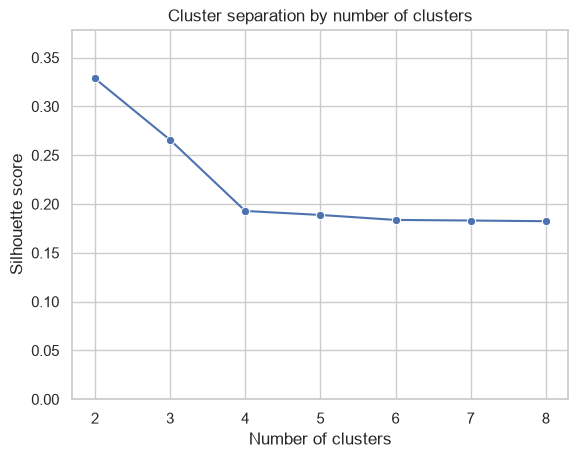

,Number of clusters,Silhouette score
0,2,0.3286
1,3,0.2657
2,4,0.1929
3,5,0.1888
4,6,0.1837
5,7,0.1831
6,8,0.1824


In [6]:
scores = pd.DataFrame(
    {"Number of clusters": [int(k) for k in metadata["silhouette_scores"]],
     "Silhouette score": list(metadata["silhouette_scores"].values())}
).sort_values("Number of clusters")
ax = sns.lineplot(data=scores, x="Number of clusters", y="Silhouette score", marker="o")
ax.set_title("Cluster separation by number of clusters")
ax.set_ylim(0, max(scores["Silhouette score"]) + 0.05)
plt.show()
scores

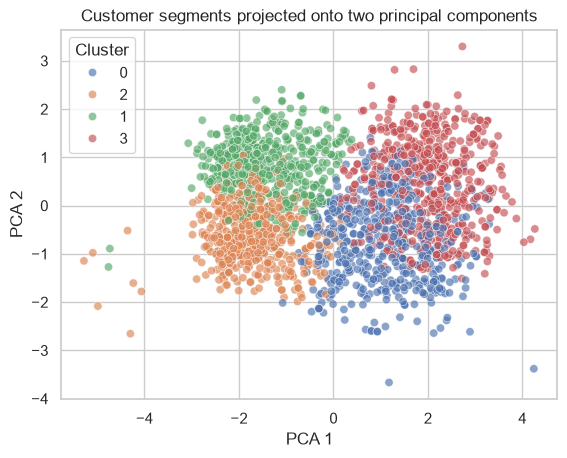

In [7]:
# Two-dimensional view for interpretation only; K-Means is trained on all seven features.
model_features = clean_data[FEATURES]
scaled = StandardScaler().fit_transform(model_features)
from sklearn.cluster import KMeans
labels = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20).fit_predict(scaled)
pca_points = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(scaled)
plot_data = pd.DataFrame({"PCA 1": pca_points[:, 0], "PCA 2": pca_points[:, 1], "Cluster": labels.astype(str)})
sns.scatterplot(data=plot_data, x="PCA 1", y="PCA 2", hue="Cluster", alpha=0.65)
plt.title("Customer segments projected onto two principal components")
plt.show()

## Takeaways

- The four-segment configuration creates distinct marketing audiences and the app exports their names and actions from model metadata instead of hard-coded cluster labels.
- `k=2` is the best-separated configuration by silhouette score. Use campaign performance and stakeholder review to determine whether the extra marketing granularity of `k=4` is worth its weaker separation.
- Predictions outside the training feature ranges should be treated as directional; the Streamlit app surfaces this warning.